In [5]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [6]:
#Take robot values from user
L1 = float(input("Enter link 1 length: ")) #5
L2 = float(input("Enter link 2 length: ")) #3

a1 = float(input("Enter joint 1 angle: ")) #30
a2 = float(input("Enter joint 2 angle: ")) #90

tx = float(input("Enter target x: ")) #5
ty = float(input("Enter target y: "))  #4

a1 = np.radians(a1)
a2 = np.radians(a2)

Enter link 1 length: 5
Enter link 2 length: 3
Enter joint 1 angle: 30
Enter joint 2 angle: 90
Enter target x: 5
Enter target y: 4


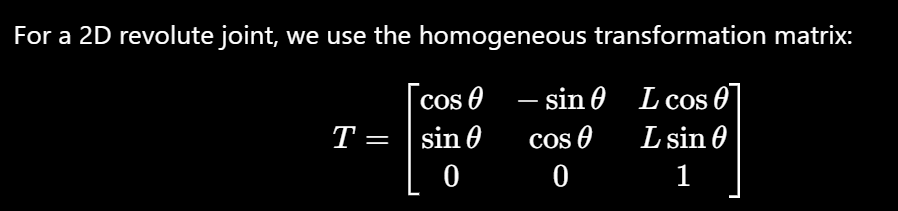

In [15]:
#Transformation matrix
def T(theta, length):
    return np.array([
        [np.cos(theta), -np.sin(theta), length*np.cos(theta)],
        [np.sin(theta),  np.cos(theta), length*np.sin(theta)],
        [0, 0, 1]
    ])

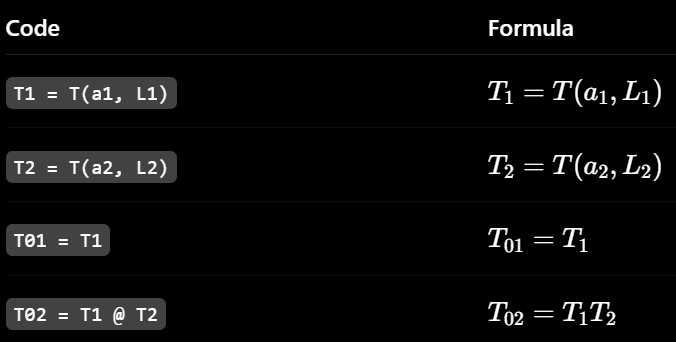

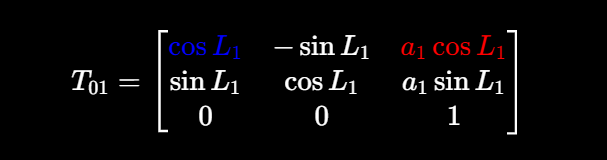

In [16]:
#Forward Kinematics
T1 = T(a1, L1)
T2 = T(a2, L2)

T01 = T1
T02 = T1 @ T2

x1 = T01[0, 2] #cosL1 a1cosL1
y1 = T01[1, 2] #sinL1 a1sinL1

x = T02[0, 2] #X = a1 cos(L1) + a2 cos(L1 + L2)


y = T02[1, 2] #Y = a1 sin(L1) + a2 sin(L1 + L2)

print("End effector position")
print("X =", x)
print("Y =", y)

End effector position
X = 2.8301270189221936
Y = 5.098076211353316


In [17]:
#Show transformation matrix
print("T01 =")
print(T01)

print("\nT02 =")
print(T02)

T01 =
[[ 0.8660254  -0.5         4.33012702]
 [ 0.5         0.8660254   2.5       ]
 [ 0.          0.          1.        ]]

T02 =
[[-0.5        -0.8660254   2.83012702]
 [ 0.8660254  -0.5         5.09807621]
 [ 0.          0.          1.        ]]


In [18]:
#Inverse Kinematics
D = (tx**2 + ty**2 - L1**2 - L2**2) / (2*L1*L2)

if D < -1 or D > 1:
    print("Target cannot be reached")

else:
    a2_ik = np.arccos(D)

    a1_ik = np.arctan2(ty, tx) - np.arctan2(
        L2*np.sin(a2_ik),
        L1 + L2*np.cos(a2_ik)
    )

    print("IK result")
    print("Joint 1 =", np.degrees(a1_ik))
    print("Joint 2 =", np.degrees(a2_ik))

IK result
Joint 1 = 11.556995846497266
Joint 2 = 76.5066011784483


In [19]:
#Verify IK with FK
T1_ik = T(a1_ik, L1)
T2_ik = T(a2_ik, L2)

T_ik = T1_ik @ T2_ik

new_x = T_ik[0, 2]
new_y = T_ik[1, 2]

error = np.sqrt((new_x - tx)**2 + (new_y - ty)**2)

print("Target position:")
print(tx, ty)

print("\nPosition from FK:")
print(new_x, new_y)

print("\nError =", error)

Target position:
5.0 4.0

Position from FK:
5.000000000000001 4.0

Error = 8.881784197001252e-16


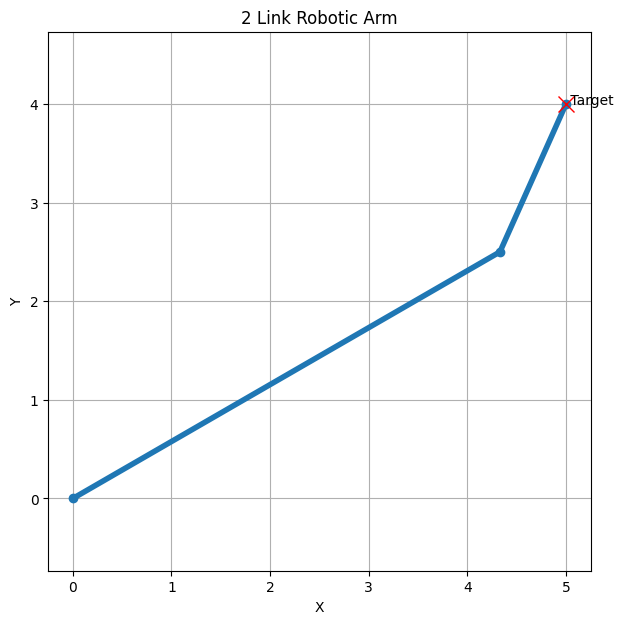

In [20]:
#2D visualization
plt.figure(figsize=(7,7))

plt.plot(
    [0, x1, new_x],
    [0, y1, new_y],
    'o-',
    linewidth=4
)

plt.plot(tx, ty, 'rx', markersize=12)

plt.text(tx, ty, " Target")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2 Link Robotic Arm")

plt.grid()
plt.axis("equal")

plt.show()

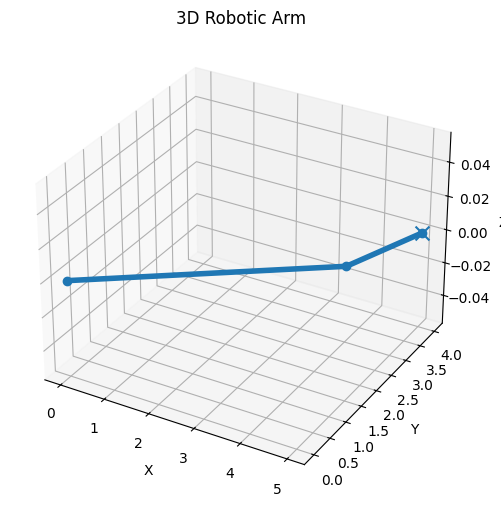

In [21]:
#3D visualization
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    [0, x1, new_x],
    [0, y1, new_y],
    [0, 0, 0],
    'o-',
    linewidth=4
)

ax.scatter(tx, ty, 0, marker='x', s=100)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("3D Robotic Arm")

plt.show()

In [14]:
#simple animation
fig, ax = plt.subplots(figsize=(7,7))

ax.set_xlim(-(L1+L2), L1+L2)
ax.set_ylim(-(L1+L2), L1+L2)

ax.grid()
ax.set_aspect("equal")

ax.plot(tx, ty, 'rx', markersize=12)

line, = ax.plot([], [], 'o-', linewidth=4)

angles1 = np.linspace(a1, a1_ik, 50)
angles2 = np.linspace(a2, a2_ik, 50)

def move(i):

    q1 = angles1[i]
    q2 = angles2[i]

    xx1 = L1*np.cos(q1)
    yy1 = L1*np.sin(q1)

    xx2 = xx1 + L2*np.cos(q1 + q2)
    yy2 = yy1 + L2*np.sin(q1 + q2)

    line.set_data([0, xx1, xx2], [0, yy1, yy2])

    return line,

ani = FuncAnimation(
    fig,
    move,
    frames=50,
    interval=50,
    blit=True
)

plt.close()

HTML(ani.to_jshtml())